In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'


import warnings
warnings.filterwarnings("ignore")

sns.set_style('darkgrid')
sns.set_palette('muted')

In [2]:
df = pd.read_csv('/content/crime data form 2020 to 2024.csv')
pd.set_option('display.max_columns', None)
df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,211507896,04/11/2021 12:00:00 AM,11/07/2020 12:00:00 AM,845,15,N Hollywood,1502,2,354,THEFT OF IDENTITY,0377,31,M,H,501,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,10/21/2020 12:00:00 AM,10/18/2020 12:00:00 AM,1845,15,N Hollywood,1521,1,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,32,M,H,102,SIDEWALK,200.0,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,230,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,12/10/2024 12:00:00 AM,10/30/2020 12:00:00 AM,1240,9,Van Nuys,933,2,354,THEFT OF IDENTITY,0377,30,M,W,501,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,354,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,12/24/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1310,7,Wilshire,782,1,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,47,F,A,101,STREET,NaN,NaN,IC,Invest Cont,331,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,10/03/2020 12:00:00 AM,09/29/2020 12:00:00 AM,1830,14,Pacific,1454,1,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,63,M,H,103,ALLEY,NaN,NaN,IC,Invest Cont,420,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [3]:
df.shape

(28854, 28)

In [4]:
df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [5]:
print(df['Status Desc'].unique(),
      "\n--------------------------------------\n",
      df['Status'].unique())

['Invest Cont' 'Adult Other' 'Adult Arrest' 'Juv Arrest' 'Juv Other'] 
--------------------------------------
 ['IC' 'AO' 'AA' 'JA' 'JO']


In [6]:
CrmData = df[['Crm Cd 1','Crm Cd 2','Crm Cd 3','Crm Cd 4']]
CrmData.isnull().sum()

,0
Crm Cd 1,0
Crm Cd 2,26475
Crm Cd 3,28761
Crm Cd 4,28850


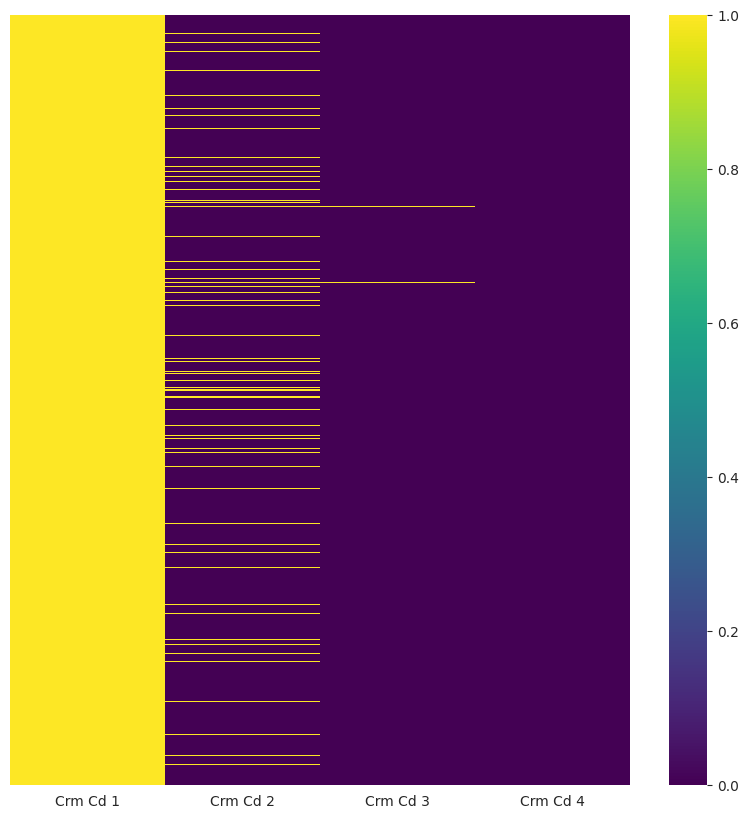

In [7]:
plt.figure(figsize=(10, 10))
sns.heatmap(CrmData.notnull(), yticklabels=False, cmap='viridis')

plt.show()

In [8]:
df.drop(columns={'DR_NO', 'AREA', 'Rpt Dist No', 'Crm Cd','Premis Cd'
                   , 'Premis Desc', 'Weapon Used Cd', 'Status', 'Cross Street'
                   , 'LAT','LON', 'Mocodes', 'Crm Cd 1','Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4'},
         inplace=True)

In [9]:
df.sample(2)

,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Part 1-2,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
26678,11/17/2020 12:00:00 AM,11/17/2020 12:00:00 AM,900,Southeast,1,VEHICLE - STOLEN,0,NaN,NaN,NaN,Invest Cont,92ND
10583,03/21/2020 12:00:00 AM,03/21/2020 12:00:00 AM,2200,Topanga,1,BRANDISH WEAPON,24,M,H,RAZOR,Adult Arrest,20500 SATICOY ST


In [10]:
df.shape

(28854, 12)

In [11]:
df.rename(columns={"Date Rptd":"notifiction_date", "DATE OCC": "crime_date", "TIME OCC": "accident_time"
                     , "AREA NAME": "area", "LOCATION": "location"
                     , "Part 1-2": "level", "Crm Cd Desc":"description_crime"
                     , "Vict Age":"vict_age", "Vict Sex":"vict_sex", "Vict Descent":"vict_descent"
                     , "Weapon Desc": "weapon_used", "Status Desc": "status"},
           inplace=True)

In [12]:
df.sample(2)

,notifiction_date,crime_date,accident_time,area,level,description_crime,vict_age,vict_sex,vict_descent,weapon_used,status,location
23517,12/27/2020 12:00:00 AM,12/24/2020 12:00:00 AM,1500,Mission,1,VEHICLE - STOLEN,0,NaN,NaN,NaN,Invest Cont,8500 N SEPULVEDA BL
25992,07/13/2020 12:00:00 AM,07/10/2020 12:00:00 AM,100,Mission,1,VEHICLE - STOLEN,0,NaN,NaN,NaN,Invest Cont,13000 DRONFIELD AV


In [13]:
df['area'].unique()

array(['N Hollywood', 'Van Nuys', 'Wilshire', 'Pacific', 'Hollenbeck',
       'Southwest', 'Northeast', 'Devonshire', 'Topanga', 'Hollywood',
       'Olympic', 'Southeast', 'Newton', 'Foothill', 'Mission', 'Rampart',
       'Central', 'West LA', '77th Street', 'West Valley', 'Harbor'],
      dtype=object)

In [14]:
df['level'].unique()

array([2, 1])

In [15]:
df['vict_descent'].unique()

array(['H', 'W', 'A', 'B', nan, 'X', 'O', 'C', 'J', 'V', 'K', 'F', 'I',
       'Z', 'L', 'G', 'P', 'D', 'U', 'S'], dtype=object)

In [16]:
df['vict_descent'].fillna('X',inplace=True)
df['vict_descent'].replace('x', 'X', inplace=True)

In [17]:
df['vict_descent'].unique()

array(['H', 'W', 'A', 'B', 'X', 'O', 'C', 'J', 'V', 'K', 'F', 'I', 'Z',
       'L', 'G', 'P', 'D', 'U', 'S'], dtype=object)

In [18]:
df.isnull().sum()

,0
notifiction_date,0
crime_date,0
accident_time,0
area,0
level,0
description_crime,0
vict_age,0
vict_sex,3903
vict_descent,0
weapon_used,18833


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28854 entries, 0 to 28853
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   notifiction_date   28854 non-null  object
 1   crime_date         28854 non-null  object
 2   accident_time      28854 non-null  int64 
 3   area               28854 non-null  object
 4   level              28854 non-null  int64 
 5   description_crime  28854 non-null  object
 6   vict_age           28854 non-null  int64 
 7   vict_sex           24951 non-null  object
 8   vict_descent       28854 non-null  object
 9   weapon_used        10021 non-null  object
 10  status             28854 non-null  object
 11  location           28854 non-null  object
dtypes: int64(3), object(9)
memory usage: 2.6+ MB
